In [71]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import curve_fit

In [69]:
sns.set_theme(style="whitegrid", font_scale=1.05)

In [20]:
moves = pd.read_csv("../../data/processed/move_level_data_v2.csv")

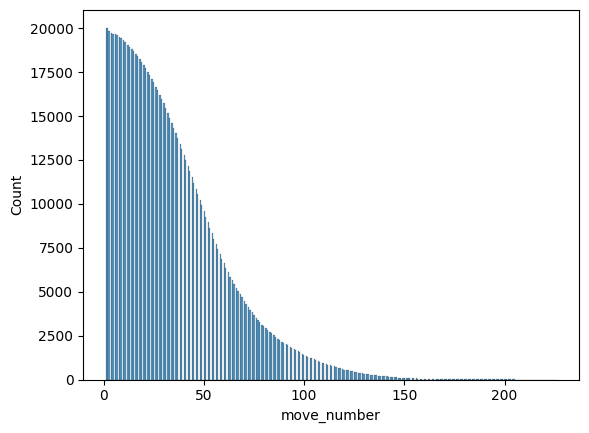

In [21]:
sns.histplot(moves['move_number']);

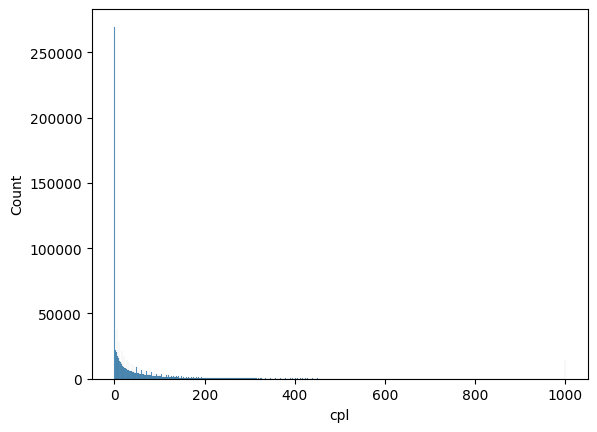

In [22]:
sns.histplot(moves['cpl']);

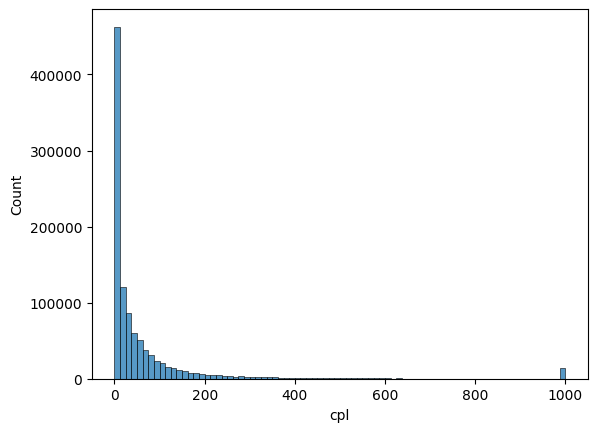

In [23]:
sns.histplot(moves["cpl"], bins=80);

In [25]:
games = pd.read_csv('../../data/raw/data.csv')

In [26]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


Merge rating info onto moves so we can stratify later

In [27]:
games_slim = games[["id", "white_rating", "black_rating"]].copy()

moves = moves.merge(games_slim, left_on="game_id", right_on="id", how="left")


In [28]:
# Assign the relevant rating per row based on color

moves["player_rating"] = np.where(
    moves["color"] == "white", moves["white_rating"], moves["black_rating"]
)

<Axes: ylabel='player_rating'>

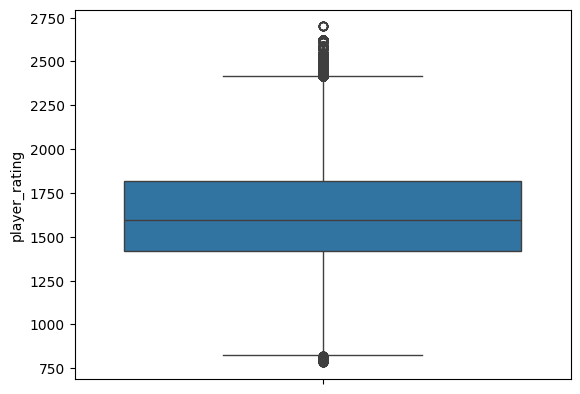

In [30]:
sns.boxplot(moves['player_rating'])

In [37]:
# create buckets (followed general guidelines on lichess )
def rating_tier(r):
    if r < 1200:  return "beginner"
    elif r < 1600: return "intermediate"
    elif r < 2000: return "club"
    else:          return "advanced"

In [38]:
moves["rating_tier"] = moves["player_rating"].apply(rating_tier)

In [39]:
moves['rating_tier'].value_counts()

rating_tier
intermediate    506566
club            455711
advanced        117841
beginner         73700
Name: count, dtype: int64

In [42]:
moves["cpl_capped"] = moves["cpl"].clip(upper=500) # reduce outlier noise (mainly from checkmate)

In [43]:
moves["move_bucket"] = (moves["player_move_number"] // 5) * 5 # Move buckets (every 5 moves = one "phase")


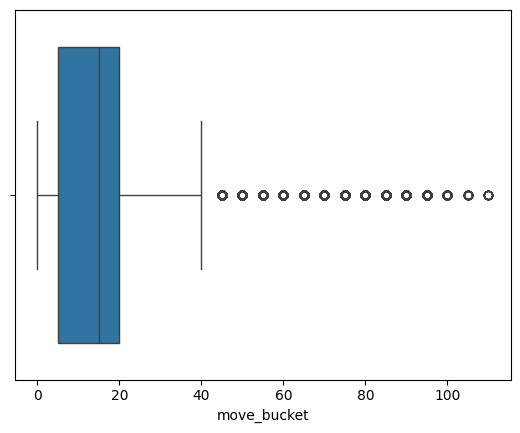

In [48]:
sns.boxplot(x=moves['move_bucket']);

In [55]:
moves_trim = moves[moves["move_bucket"].between(0, 50)].copy() # focus on bulk of games without sparse tail

In [68]:
TIER_ORDER = ['beginner', 'intermediate', 'club', 'advanced']
TIER_COLORS = ["#E24B4A", "#BA7517", "#378ADD", "#1D9E75"]
TIER_PAL    = dict(zip(TIER_ORDER, TIER_COLORS))
#  set up colors and order for graphs

In [57]:
print("Rows in trimmed moves df:", len(moves_trim))
print(moves_trim[["player_move_number", "cpl_capped", "is_blunder", "difficulty", "rating_tier"]].describe())

Rows in trimmed moves df: 1132836
       player_move_number    cpl_capped    is_blunder    difficulty
count        1.132836e+06  1.132836e+06  1.132836e+06  1.132836e+06
mean         1.664552e+01  5.686190e+01  1.609183e-01  6.441766e+01
std          1.194967e+01  9.958372e+01  3.674557e-01  1.431546e+02
min          1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%          7.000000e+00  1.000000e+00  0.000000e+00  6.000000e+00
50%          1.400000e+01  1.800000e+01  0.000000e+00  1.800000e+01
75%          2.400000e+01  6.300000e+01  0.000000e+00  5.300000e+01
max          5.400000e+01  5.000000e+02  1.000000e+00  1.000000e+03


investigate fatigue curve

In [58]:
agg = (
    moves_trim.groupby("player_move_number")
    .agg(
        blunder_rate=("is_blunder", "mean"),
        mean_cpl=("cpl_capped", "mean"),
        mean_difficulty=("difficulty", "mean"),
        n=("is_blunder", "count"),
    )
    .reset_index()
)

In [ ]:
# 3 move rolling average for clearer signal
agg["blunder_smooth"] = agg["blunder_rate"].rolling(3, center=True, min_periods=1).mean()
agg["cpl_smooth"]     = agg["mean_cpl"].rolling(3, center=True, min_periods=1).mean()


Model fit (blunder rate ~ move number):
  Linear      R² = 0.086
  Logarithmic R² = 0.420
  Exponential R² = 0.802


C:\Users\Jaden\AppData\Local\Temp\ipykernel_14240\395795092.py:92: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jaden\AppData\Local\Temp\ipykernel_14240\395795092.py:93: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig("fatigue_core_curve.png", dpi=150, bbox_inches="tight")
d:\PythonDevelopment\datablog-decision-fatigue\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


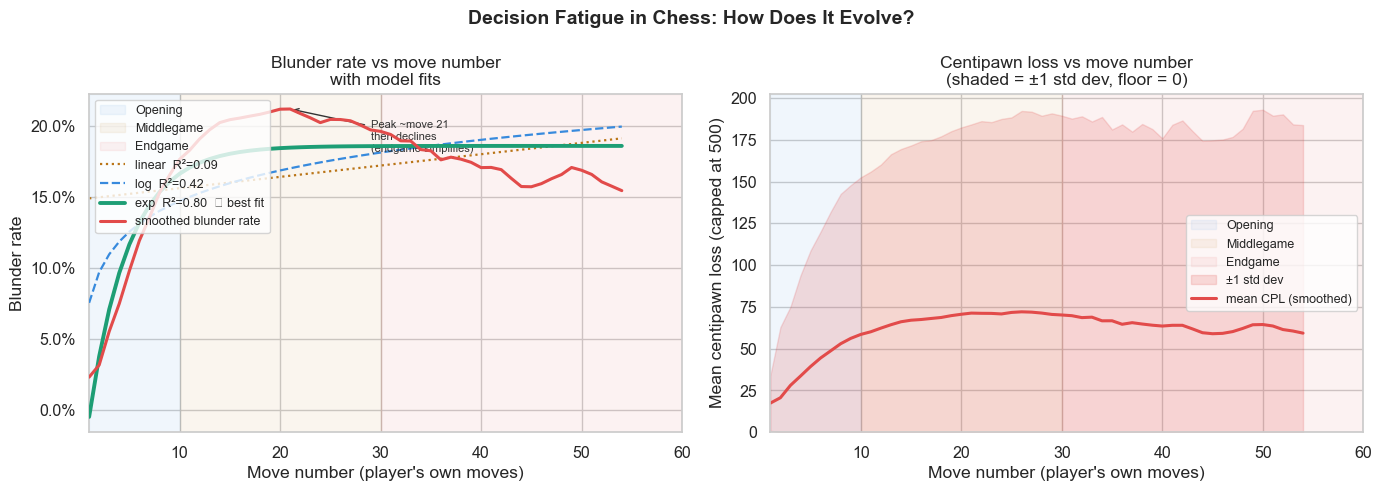

Saved: fatigue_core_curve.png


In [76]:
x = agg["player_move_number"].values.astype(float)
y = agg["blunder_smooth"].values
 
def exp_func(x, a, b, c): return a * np.exp(b * x) + c
def log_func(x, a, b):    return a * np.log(x) + b
def lin_func(x, a, b):    return a * x + b
 
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot
 
try:
    popt_exp, _ = curve_fit(exp_func, x, y, p0=[0.001, 0.05, 0.02], maxfev=5000)
    y_exp = exp_func(x, *popt_exp)
except Exception:
    y_exp = None
 
popt_log, _ = curve_fit(log_func, x, y)
y_log = log_func(x, *popt_log)
 
popt_lin, _ = curve_fit(lin_func, x, y)
y_lin = lin_func(x, *popt_lin)
 
r2_log = r_squared(y, y_log)
r2_lin = r_squared(y, y_lin)
r2_exp = r_squared(y, y_exp) if y_exp is not None else None
 
print(f"\nModel fit (blunder rate ~ move number):")
print(f"  Linear      R² = {r2_lin:.3f}")
print(f"  Logarithmic R² = {r2_log:.3f}")
if r2_exp: print(f"  Exponential R² = {r2_exp:.3f}")
 
# ── Plot ──────────────────────────────────────
def add_phase_bands(ax):
    ax.axvspan(1,  10, alpha=0.07, color="#378ADD", label="Opening")
    ax.axvspan(10, 30, alpha=0.07, color="#BA7517", label="Middlegame")
    ax.axvspan(30, 60, alpha=0.07, color="#E24B4A", label="Endgame")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Fatigue in Chess: How Does It Evolve?", fontsize=14, fontweight="bold")
 
# Left — blunder rate + fits
ax = axes[0]
add_phase_bands(ax)
 
# Plot weaker fits first (behind), exp fit last (on top, thickest)
ax.plot(x, y_lin, color="#BA7517", lw=1.6, ls=":",  label=f"linear  R²={r2_lin:.2f}", zorder=2)
ax.plot(x, y_log, color="#378ADD", lw=1.6, ls="--", label=f"log  R²={r2_log:.2f}", zorder=3)
if y_exp is not None:
    ax.plot(x, y_exp, color="#1D9E75", lw=2.8, ls="-", label=f"exp  R²={r2_exp:.2f}  ✓ best fit", zorder=4)
 
sns.lineplot(data=agg, x="player_move_number", y="blunder_smooth",
             color="#E24B4A", lw=2.2, label="smoothed blunder rate", zorder=5, ax=ax)
 
# Annotate the peak
peak_move = agg.loc[agg["blunder_smooth"].idxmax(), "player_move_number"]
peak_val  = agg["blunder_smooth"].max()
ax.annotate(
    f"Peak ~move {peak_move}\nthen declines\n(endgame simplifies)",
    xy=(peak_move, peak_val),
    xytext=(peak_move + 8, peak_val - 0.03),
    fontsize=8, color="#333",
    arrowprops=dict(arrowstyle="->", color="#333", lw=1),
)
 
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_xlim(1, 60)
ax.set_xlabel("Move number (player's own moves)")
ax.set_ylabel("Blunder rate")
ax.set_title("Blunder rate vs move number\nwith model fits")
ax.legend(fontsize=9, loc="upper left")
 
# Right — CPL with correct confidence band (clipped at 0)
ax2 = axes[1]
add_phase_bands(ax2)
 
cpl_upper = (agg["cpl_smooth"] + agg["cpl_std"]).clip(lower=0)
cpl_lower = (agg["cpl_smooth"] - agg["cpl_std"]).clip(lower=0)   # CPL can't be negative
ax2.fill_between(x, cpl_lower, cpl_upper, alpha=0.18, color="#E24B4A", label="±1 std dev")
 
sns.lineplot(data=agg, x="player_move_number", y="cpl_smooth",
             color="#E24B4A", lw=2.2, label="mean CPL (smoothed)", ax=ax2)
 
ax2.set_xlim(1, 60)
ax2.set_ylim(bottom=0)   # enforce non-negative y axis
ax2.set_xlabel("Move number (player's own moves)")
ax2.set_ylabel("Mean centipawn loss (capped at 500)")
ax2.set_title("Centipawn loss vs move number\n(shaded = ±1 std dev, floor = 0)")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("fatigue_core_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_core_curve.png")

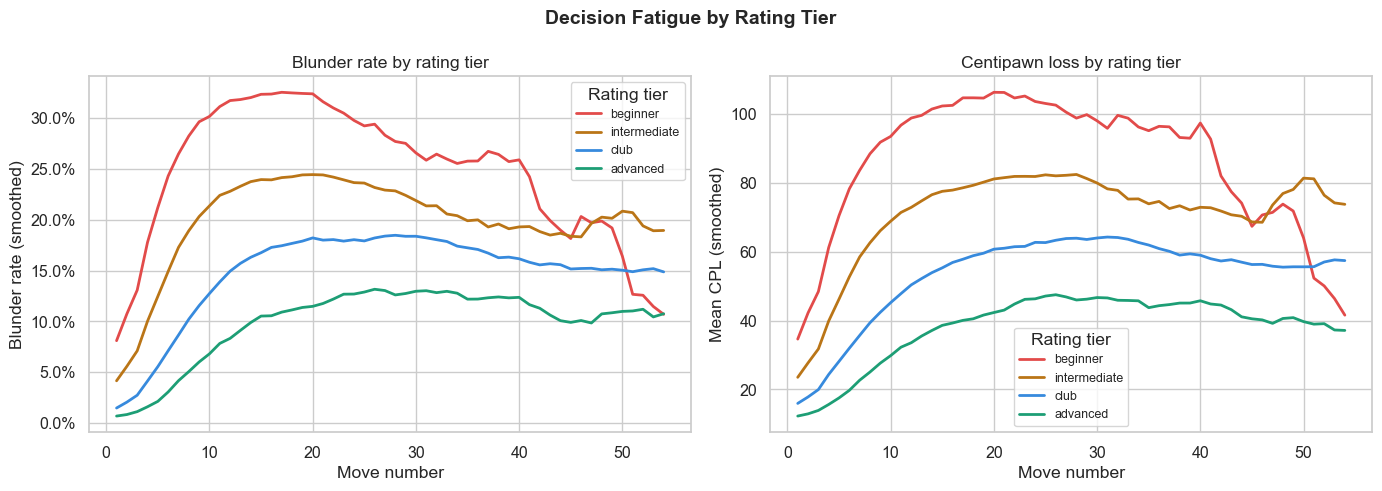

Saved: fatigue_by_rating.png


In [77]:
tier_agg_rows = []
for tier in TIER_ORDER:
    sub = moves_trim[moves_trim["rating_tier"] == tier]
    grp = (
        sub.groupby("player_move_number")
        .agg(blunder_rate=("is_blunder", "mean"), mean_cpl=("cpl_capped", "mean"))
        .reset_index()
    )
    grp["blunder_smooth"] = grp["blunder_rate"].rolling(5, center=True, min_periods=1).mean()
    grp["cpl_smooth"]     = grp["mean_cpl"].rolling(5, center=True, min_periods=1).mean()
    grp["rating_tier"]    = tier
    tier_agg_rows.append(grp)
 
tier_agg = pd.concat(tier_agg_rows, ignore_index=True)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Fatigue by Rating Tier", fontsize=14, fontweight="bold")
 
sns.lineplot(data=tier_agg, x="player_move_number", y="blunder_smooth",
             hue="rating_tier", hue_order=TIER_ORDER, palette=TIER_PAL,
             lw=2, ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].set_xlabel("Move number")
axes[0].set_ylabel("Blunder rate (smoothed)")
axes[0].set_title("Blunder rate by rating tier")
axes[0].legend(title="Rating tier", fontsize=9)
 
sns.lineplot(data=tier_agg, x="player_move_number", y="cpl_smooth",
             hue="rating_tier", hue_order=TIER_ORDER, palette=TIER_PAL,
             lw=2, ax=axes[1])
axes[1].set_xlabel("Move number")
axes[1].set_ylabel("Mean CPL (smoothed)")
axes[1].set_title("Centipawn loss by rating tier")
axes[1].legend(title="Rating tier", fontsize=9)
 
plt.tight_layout()
plt.savefig("fatigue_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_by_rating.png")

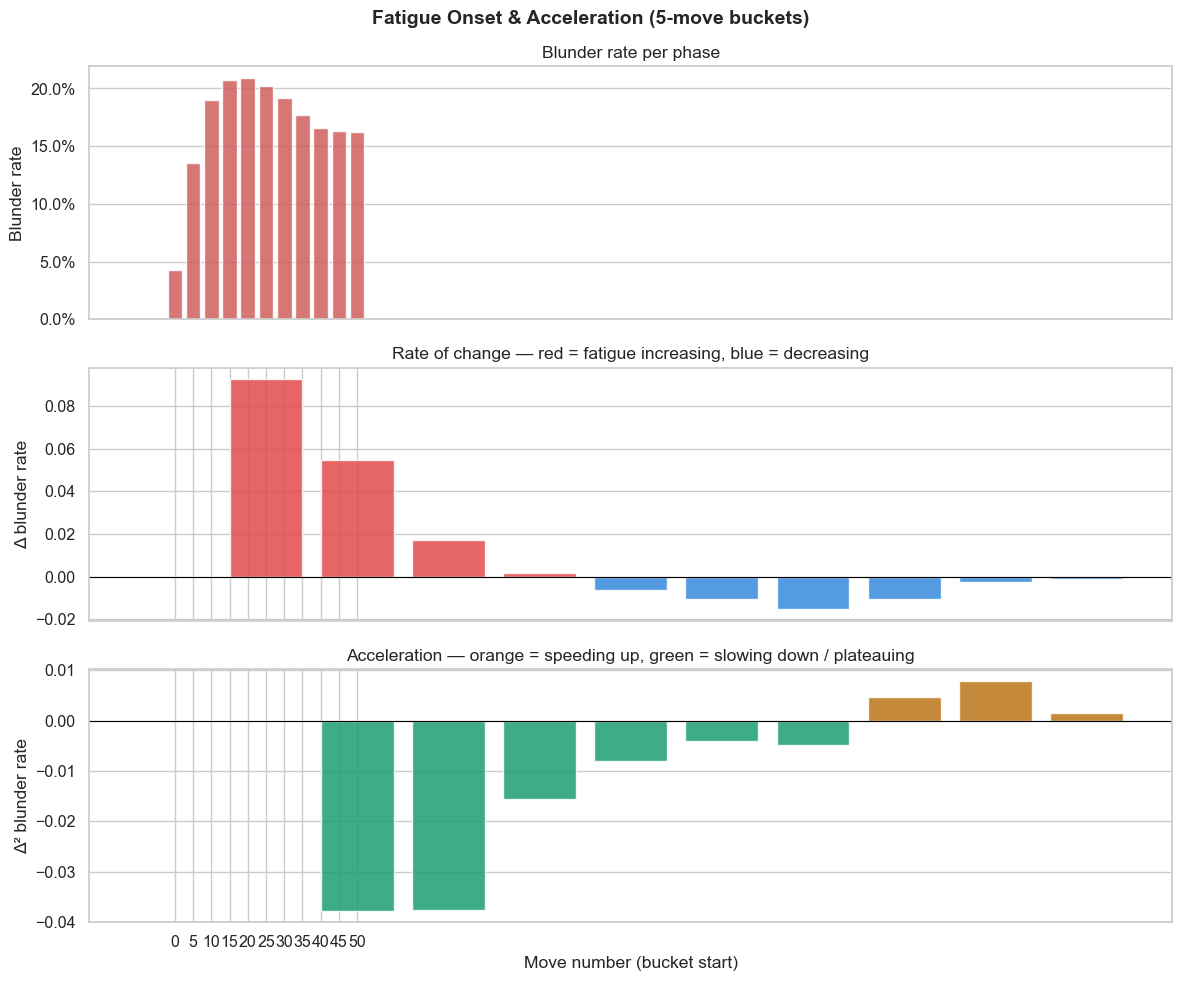

Saved: fatigue_derivatives.png


In [78]:
bucket_agg = (
    moves_trim.groupby("move_bucket")
    .agg(blunder_rate=("is_blunder", "mean"), mean_cpl=("cpl_capped", "mean"), n=("is_blunder", "count"))
    .reset_index()
)
bucket_agg["delta_blunder"] = bucket_agg["blunder_rate"].diff()
bucket_agg["accel_blunder"] = bucket_agg["delta_blunder"].diff()
bucket_agg["delta_color"]   = bucket_agg["delta_blunder"].apply(lambda v: "#E24B4A" if v > 0 else "#378ADD")
bucket_agg["accel_color"]   = bucket_agg["accel_blunder"].apply(lambda v: "#BA7517" if v > 0 else "#1D9E75")
 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Fatigue Onset & Acceleration (5-move buckets)", fontsize=14, fontweight="bold")
 
sns.barplot(data=bucket_agg, x="move_bucket", y="blunder_rate",
            color="#E24B4A", alpha=0.85, ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].set_ylabel("Blunder rate")
axes[0].set_title("Blunder rate per phase")
axes[0].set_xlabel("")
 
# Diverging bars use matplotlib directly (seaborn barplot doesn't support per-bar colours)
axes[1].bar(bucket_agg["move_bucket"], bucket_agg["delta_blunder"].fillna(0),
            width=4, color=bucket_agg["delta_color"], alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Δ blunder rate")
axes[1].set_title("Rate of change — red = fatigue increasing, blue = decreasing")
axes[1].set_xlabel("")
 
axes[2].bar(bucket_agg["move_bucket"], bucket_agg["accel_blunder"].fillna(0),
            width=4, color=bucket_agg["accel_color"], alpha=0.85)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_ylabel("Δ² blunder rate")
axes[2].set_xlabel("Move number (bucket start)")
axes[2].set_title("Acceleration — orange = speeding up, green = slowing down / plateauing")
 
plt.tight_layout()
plt.savefig("fatigue_derivatives.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_derivatives.png")

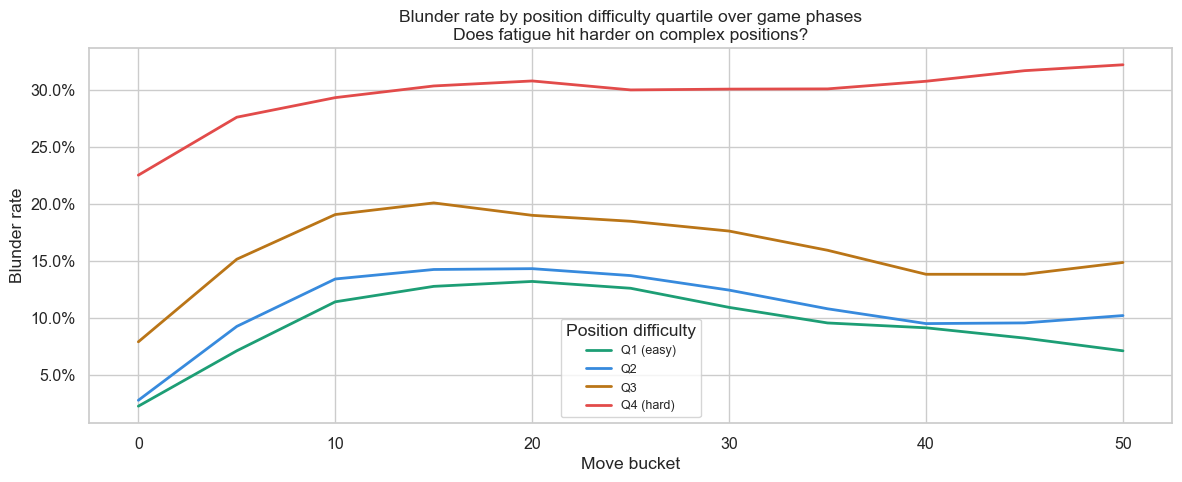

Saved: fatigue_vs_difficulty.png


In [79]:
moves_trim["difficulty_q"] = pd.qcut(
    moves_trim["difficulty"], q=4, labels=["Q1 (easy)", "Q2", "Q3", "Q4 (hard)"]
)
diff_agg = (
    moves_trim.groupby(["move_bucket", "difficulty_q"], observed=True)["is_blunder"]
    .mean()
    .reset_index()
    .rename(columns={"is_blunder": "blunder_rate"})
)
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=diff_agg, x="move_bucket", y="blunder_rate",
             hue="difficulty_q",
             palette=["#1D9E75", "#378ADD", "#BA7517", "#E24B4A"],
             lw=2, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel("Move bucket")
ax.set_ylabel("Blunder rate")
ax.set_title("Blunder rate by position difficulty quartile over game phases\n"
             "Does fatigue hit harder on complex positions?")
ax.legend(title="Position difficulty", fontsize=9)
plt.tight_layout()
plt.savefig("fatigue_vs_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_vs_difficulty.png")

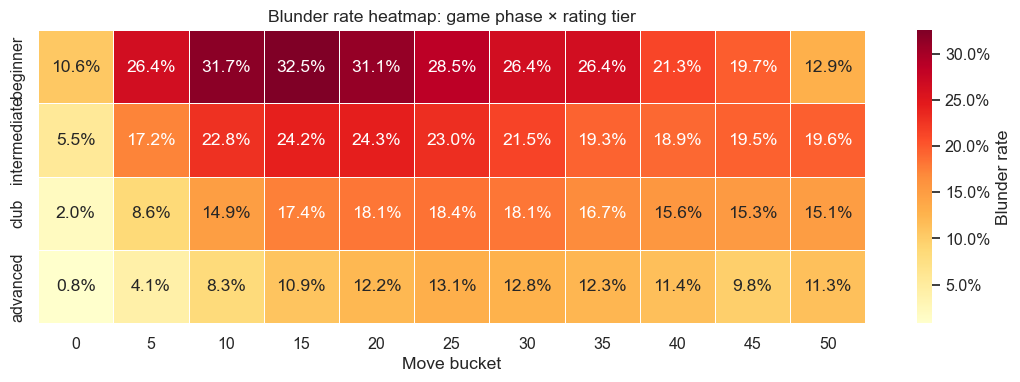

Saved: fatigue_heatmap.png


In [80]:
heatmap_data = (
    moves_trim.groupby(["move_bucket", "rating_tier"], observed=True)["is_blunder"]
    .mean()
    .unstack("rating_tier")
    .reindex(columns=TIER_ORDER)
)
annot = heatmap_data.apply(lambda col: col.map(lambda v: f"{v:.1%}" if pd.notna(v) else ""))
 
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=annot.T,
    fmt="",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Blunder rate", "format": mtick.PercentFormatter(xmax=1, decimals=1)},
    ax=ax,
)
ax.set_xlabel("Move bucket")
ax.set_ylabel("")
ax.set_title("Blunder rate heatmap: game phase × rating tier")
plt.tight_layout()
plt.savefig("fatigue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_heatmap.png")

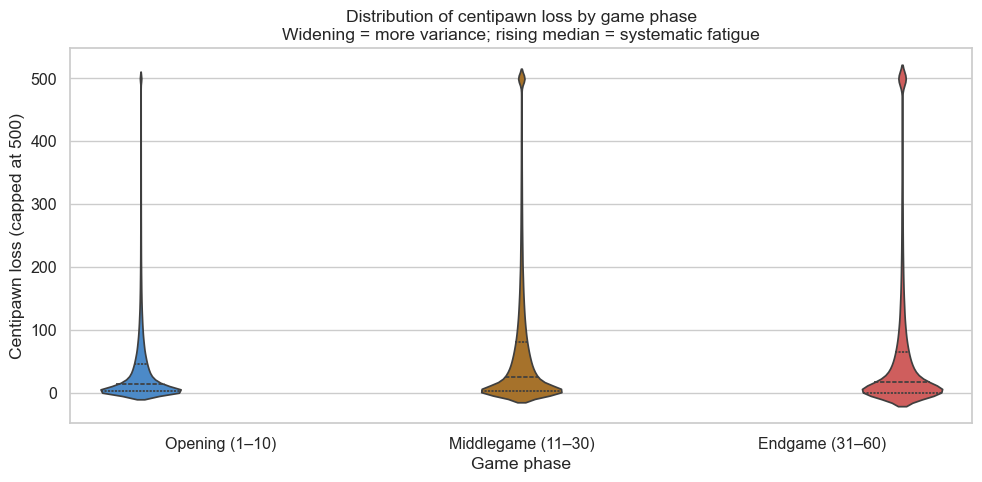

Saved: fatigue_cpl_violin.png


In [81]:
moves_trim["game_phase"] = pd.cut(
    moves_trim["player_move_number"],
    bins=[0, 10, 30, 60],
    labels=["Opening (1–10)", "Middlegame (11–30)", "Endgame (31–60)"]
)
 
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=moves_trim,
    x="game_phase", y="cpl_capped",
    hue="game_phase",
    palette=["#378ADD", "#BA7517", "#E24B4A"],
    inner="quartile",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Game phase")
ax.set_ylabel("Centipawn loss (capped at 500)")
ax.set_title("Distribution of centipawn loss by game phase\n"
             "Widening = more variance; rising median = systematic fatigue")
plt.tight_layout()
plt.savefig("fatigue_cpl_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fatigue_cpl_violin.png")